<a href="https://colab.research.google.com/github/project-ida/arpa-e-experiments/blob/main/analysis/nassisi-04/Nassisi_4_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="https://nbviewer.org/github/project-ida/arpa-e-experiments/blob/main/analysis/nassisi-04/Nassisi_4_revised.ipynb" target="_parent"><img src="https://nbviewer.org/static/img/nav_logo.svg" alt="Open In nbviewer" width="100"/></a>

# 2025-04-04 Nassisi 3 Palladium wire

A 784 mg Palladium wire is gas loaded with deuterium, in a 0.6 L chamber. There is a 30 day soaking period, where the deuterium is allowed to diffuse through the wire, followed by a 30 day laser irradiation period. During this time, the chamber was relocated from 13-3100 to the basement of building 6, where it was exposed for 1 hour a day to a UV pulsed laser.

In [1]:
# Makes Libs accessible and runs notebook from same location regardless of whether colab or local
!pip install colocal -q
import colocal
root, branch, cwd = colocal.setup("https://github.com/project-ida/arpa-e-experiments")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 20.0 MB/s eta 0:00:00
[Colab] Repo: arpa-e-experiments | Branch: None
[Colab] Repo root added to sys.path
[Colab] Working directory set to: .


In [2]:
# Libraries and helper functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from IPython.display import Image
from IPython.display import Video
from IPython.display import HTML

# Use our custom helper functions
# - process_data
# - plot_panels
# - plot_panels_with_scatter
# - print_info
# - load_data
from libs.helpers import *

# Necessary for using load_data on password protected data urls
# - authenticate
# - get_credentials
from libs.auth import *

In [3]:
meta = {
    "descriptor" : "Palladium wire" # This will go into the title of all plots
}

## Reading the raw data

### Temperature

In [4]:
# Read the tempearture data
temperature_df = load_data('https://nucleonics.mit.edu/data/csv-files/completed%20arpa-e%20runs/Nassisi4/Nassisi4-2-fullres.csv')

Data file loaded successfully!


In [5]:
# Print out basic description of the data, including any NaNs
print_info(temperature_df)

Metric,Value
Measurements,"5,658,939"
Start,2025-04-16 12:00:00.528000
End,2025-06-27 11:59:59.142524
Mean Δt,1.099287 s
Median Δt,1.072000 s
Most common Δt,1.072 s
99th percentile Δt,1.096 s
Maximum Δt,92697.343 s
Within 1 ± 0.1 s,"5,617,801 (99.27%)"
Outside tolerance,"41,137 (0.73%)"


Plot the temperature for the soaking phase

In [6]:
soak_start_time = '2025-04-17 13:00:00'
soak_end_time  = '2025-05-19 15:00:00'

soak_temperature_df = temperature_df[soak_start_time:soak_end_time]

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


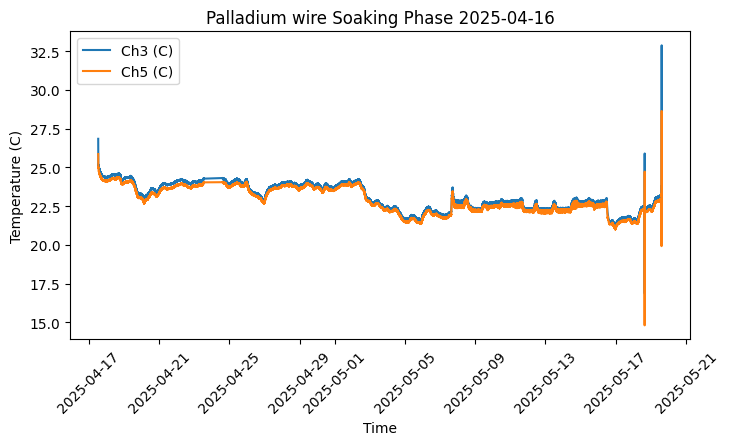

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(soak_temperature_df['Ch3 (C)'], label='Ch3 (C)')
plt.plot(soak_temperature_df['Ch5 (C)'], label='Ch5 (C)')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} Soaking Phase {temperature_df.index[0].date()}")
plt.legend()
plt.show()

Plot the temperature for the laser phase

In [8]:
laser_start_time = '2025-05-19 19:00:00'
laser_end_time  = '2025-06-23 19:00:00'

laser_temperature_df = temperature_df[laser_start_time:laser_end_time]

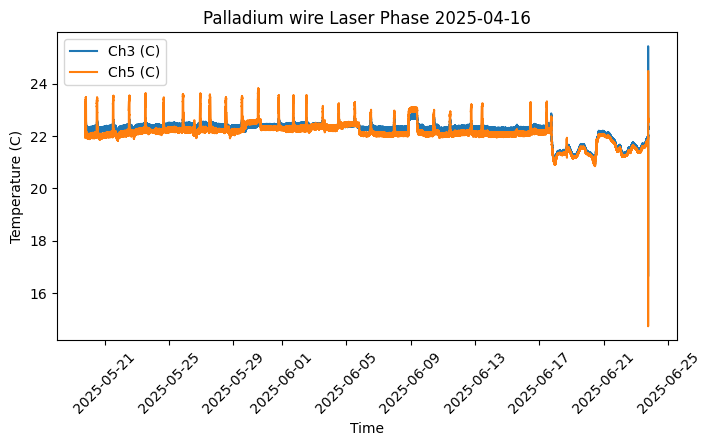

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(laser_temperature_df['Ch3 (C)'], label='Ch3 (C)')
plt.plot(laser_temperature_df['Ch5 (C)'], label='Ch5 (C)')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} Laser Phase {temperature_df.index[0].date()}")
plt.legend()
plt.show()

#Pressure

In [10]:
# Read the pressure data
pressure_df = load_data('https://nucleonics.mit.edu/data/csv-files/completed%20arpa-e%20runs/Nassisi4/Nassisi4-1-fullres.csv')

Data file loaded successfully!


In [11]:
#Filter pressure_df to include only values of 'Pressure Ch3 (bar)' between 0 and 1.5

pressure_filtered_df = pressure_df[(pressure_df['Pressure Ch3 (bar)'] >= 1.3) & (pressure_df['Pressure Ch3 (bar)'] <= 1.47)]

In [12]:
# Print out basic description of the data, including any NaNs
print_info(pressure_df)

Metric,Value
Measurements,"5,951,253"
Start,2025-04-16 12:00:00.125370
End,2025-06-27 11:59:59.350009
Mean Δt,1.045293 s
Median Δt,1.016729 s
Most common Δt,1.016 s
99th percentile Δt,1.070 s
Maximum Δt,92697.243 s
Within 1 ± 0.1 s,"5,933,022 (99.69%)"
Outside tolerance,"18,230 (0.31%)"


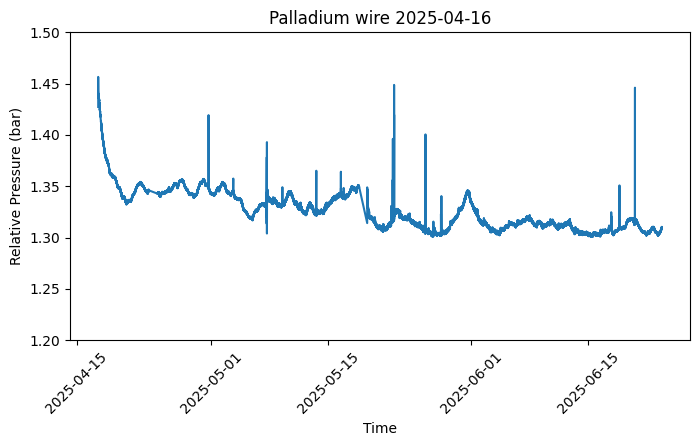

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(pressure_filtered_df['Pressure Ch3 (bar)'])
plt.xlabel('Time')
plt.ylabel('Relative Pressure (bar)')
plt.ylim(1.2, 1.5)
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {pressure_df.index[0].date()}")
plt.show()

After the soaking period, the chamber was evacuated, and refilled with deuterium gas, following the original protocol used by Nassisi.

This chamber looks more leak tight than the previous runs. On the other hand, the pressure fluctuates a bit more. Let's compare with the ambient pressure in 13-3100 to see if the fluctuations are correlated.

In [14]:
ambientpressure_df = load_data('https://nucleonics.mit.edu/data/csv-files/completed%20arpa-e%20runs/Nassisi4/Nassisi4-9-fullres.csv')

Data file loaded successfully!


In [15]:
# Print out basic description of the data, including any NaNs
print_info(ambientpressure_df)

Metric,Value
Measurements,"5,388,197"
Start,2025-04-16 16:34:14.277752
End,2025-06-27 11:59:59.172280
Mean Δt,1.151470 s
Median Δt,1.013948 s
Most common Δt,1.013 s
99th percentile Δt,2.615 s
Maximum Δt,176703.122 s
Within 1 ± 0.1 s,"5,192,048 (96.36%)"
Outside tolerance,"196,148 (3.64%)"


In [16]:
ambientpressure_df = ambientpressure_df[((ambientpressure_df['Pressure (mbar)']) < 2000) & ((ambientpressure_df['Pressure (mbar)']) > 800)]

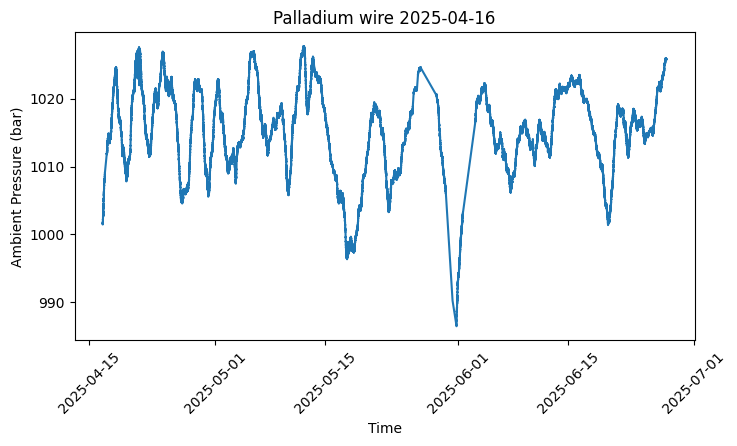

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(ambientpressure_df['Pressure (mbar)'])
plt.xlabel('Time')
plt.ylabel('Ambient Pressure (bar)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {ambientpressure_df.index[0].date()}")
plt.show()

To estimate the loading from the pressure data, we need to synchronize it with the temperature data.

The `process_data` function below strips the intersecond time resolution from the data in order to place each diagonsitc measurement on a common time index. Any duplicate datapoints that arrise are averaged. Any NaNs that are generated after merging the dataframes are removed by linear interpolation.

In [18]:
combined_df = process_data([temperature_df, pressure_filtered_df, ambientpressure_df], meta)
combined_df.head()

,Ch3 (C),Ch5 (C),#Voltage Ch3 (V),#Current Ch3 (mA),Pressure Ch3 (bar),Pressure (mbar)
time,,,,,,
2025-04-17 12:59:33,33.728,30.449,3.356232,7.312052,1.427237,1014.50
2025-04-17 12:59:34,33.246,30.295,3.378793,7.361205,1.448418,1014.50
2025-04-17 12:59:35,32.383,30.007,3.387256,7.379643,1.456364,1014.49
2025-04-17 12:59:36,31.561,29.597,3.387392,7.379938,1.456491,1014.49
2025-04-17 12:59:37,30.829,29.169,3.383794,7.372099,1.453113,1014.49


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


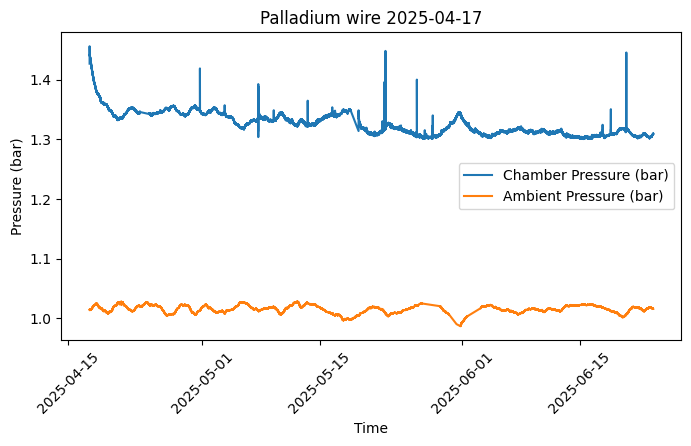

In [19]:
#Plot Pressure Ch3 (bar) and Pressure (mbar) together
plt.figure(figsize=(8, 4))
plt.plot(combined_df['Pressure Ch3 (bar)'], label='Chamber Pressure (bar)')
plt.plot(combined_df['Pressure (mbar)']/1000, label='Ambient Pressure (bar)')
plt.xlabel('Time')
plt.ylabel('Pressure (bar)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {combined_df.index[0].date()}")
plt.legend()
plt.show()

With the ambient pressure reading, we can convert the relative pressure gauge reading to an absolute pressure reading.

In [20]:
combined_df['Absolute Pressure (bar)'] = combined_df['Pressure Ch3 (bar)'] + combined_df['Pressure (mbar)']/1000
combined_df.head()

,Ch3 (C),Ch5 (C),#Voltage Ch3 (V),#Current Ch3 (mA),Pressure Ch3 (bar),Pressure (mbar),Absolute Pressure (bar)
time,,,,,,,
2025-04-17 12:59:33,33.728,30.449,3.356232,7.312052,1.427237,1014.50,2.441737
2025-04-17 12:59:34,33.246,30.295,3.378793,7.361205,1.448418,1014.50,2.462918
2025-04-17 12:59:35,32.383,30.007,3.387256,7.379643,1.456364,1014.49,2.470854
2025-04-17 12:59:36,31.561,29.597,3.387392,7.379938,1.456491,1014.49,2.470981
2025-04-17 12:59:37,30.829,29.169,3.383794,7.372099,1.453113,1014.49,2.467603


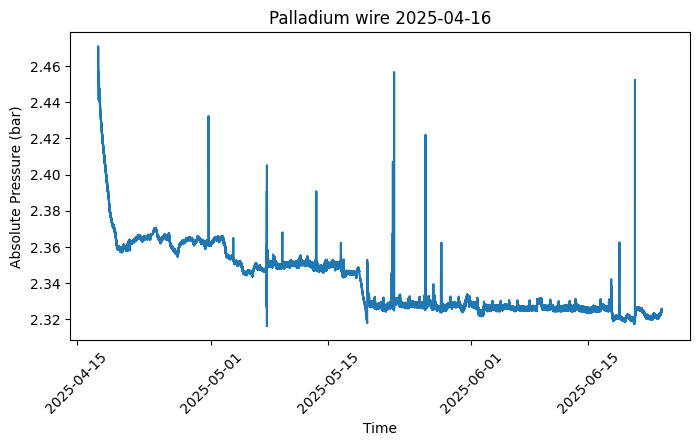

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['Absolute Pressure (bar)'])
plt.xlabel('Time')
plt.ylabel('Absolute Pressure (bar)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {pressure_df.index[0].date()}")
plt.show()

This also smooths out a lot of the variation in the gauge reading that was due to fluctuations in the ambient pressure (the large discontinuity around 05/16 is when the deuterium was replenished). We'll plot the pressure during the soaking phase.

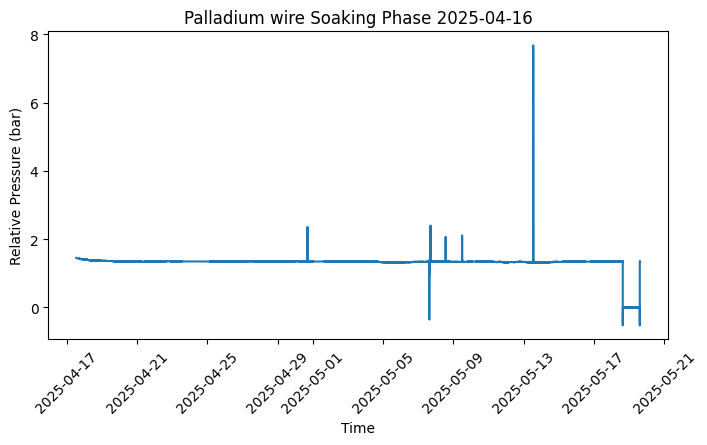

In [22]:
#Pull the pressure data during the soaking period
soak_pressure_df = pressure_df[soak_start_time:soak_end_time]
plt.figure(figsize=(8, 4))
plt.plot(soak_pressure_df['Pressure Ch3 (bar)'])
plt.xlabel('Time')
plt.ylabel('Relative Pressure (bar)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} Soaking Phase {pressure_df.index[0].date()}")
plt.show()


Let's focus on the early loading period.

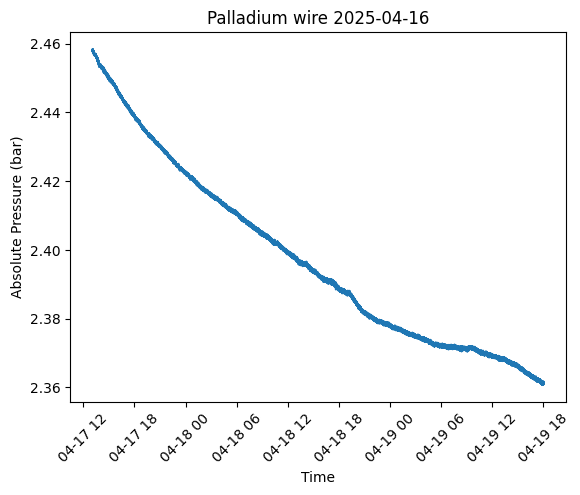

In [23]:
load_pressure_df = combined_df['2025-04-17 13:05':'2025-04-19 18:00']
plt.plot(load_pressure_df['Absolute Pressure (bar)'])
plt.xlabel('Time')
plt.ylabel('Absolute Pressure (bar)')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {pressure_df.index[0].date()}")
plt.show()

### Inferring deuterium loading

The deuterium loading is inferred by using the ideal gas law to calculate how many deuterium molecules are present in the gas over time:

$$N_{D_2} = \frac{PV}{k_B T}$$

and associating any changes $\Delta N_{D_2}$ with deuteium entering the lattice. We can then calculate the loading based on the number of lattice atoms $N_{lattice}$, calculated by dividing the wire mass by the atomic mass of Pd:

$$N_{lattice} = 4.437\times 10^{21}$$

The loading is then:

$$2\frac{\Delta N_{D_2}}{N_{lattice}}$$

The factor 2 arrises because a single $D_2$ molecule becomes 2 deuterons once inside the lattice.

In [24]:
# Constants
V = 0.6 / 1000  # Volume of the container in m^3
kB = 1.3806503e-23  # Boltzmann constant in J/K
N_lattice = 4.437e21

In [25]:
combined_df['$D_2$ molecules'] = (combined_df['Absolute Pressure (bar)']*1e5 * V) / (kB * (combined_df['Ch3 (C)'] + 273.15))

In [26]:
combined_df['D/Pd Loading'] = 2*(combined_df['$D_2$ molecules']['2025-04-17 13:05:00'] - combined_df['$D_2$ molecules']) / N_lattice

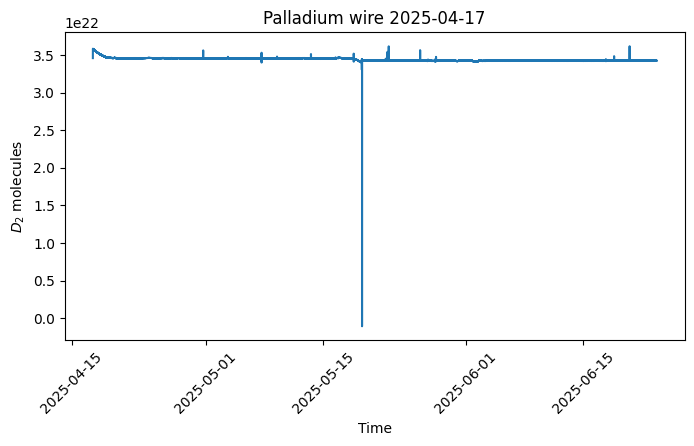

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['$D_2$ molecules'])
plt.xlabel('Time')
plt.ylabel('$D_2$ molecules')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {combined_df.index[0].date()}")
plt.show()

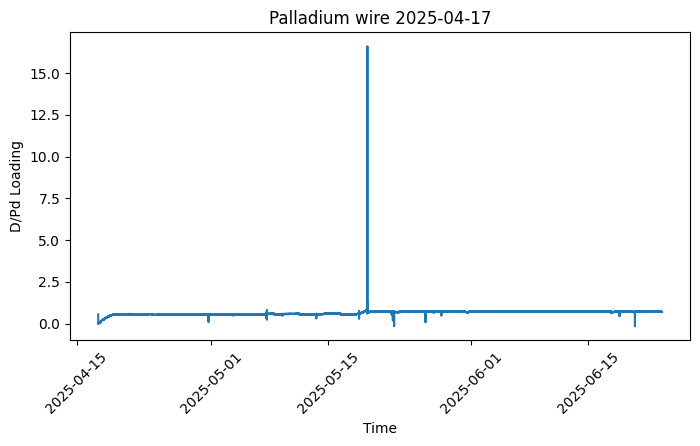

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['D/Pd Loading'])
plt.xlabel('Time')
plt.ylabel('D/Pd Loading')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {combined_df.index[0].date()}")
plt.show()

Again, focusing only on the early loading period:

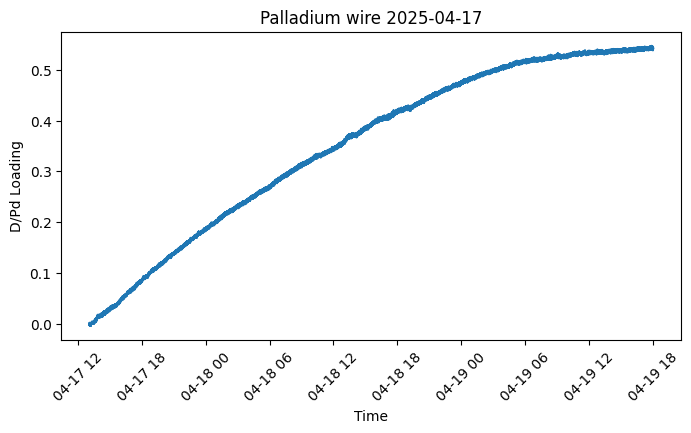

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['D/Pd Loading']['2025-04-17 13:05':'2025-04-19 18:00'])
plt.xlabel('Time')
plt.ylabel('D/Pd Loading')
plt.xticks(rotation=45)
plt.title(f"{meta['descriptor']} {combined_df.index[0].date()}")
plt.show()


We can fit the loading to a exponential dependence. The justification follows from application of Fick's second law: for an initially hydrogen free cylinder of radius R, and for a fixed boundary concentration C(0,t) = C$_s$, the concentration at depth r from the surface is
$$C(r,t)=C_s[1-2∑_{n=1}^∞\frac{J_0(\alpha_nr/R)}{\alpha_nJ_1(\alpha_n)})\mathrm{exp}(-\frac{\alpha_n^2Dt}{R^2})]$$
where D is the diffusion coefficient, $J_0$ and $J_1$ are Bessel functions of the first and second kind, and $\alpha_n$ are the positive zeros of $J_0$. By integrating the concentration over the whole cylinder, we arrive at the average concentration of hydrogen
$$C(t)=C_s[1-4\sum_{0}^{∞}\frac{1}{\alpha_n^2}\mathrm{exp}(-\frac{\alpha_n^2Dt}{R^2})]$$

At long times, the first term dominates:
$$C(t)\approx C_s[1-\frac{4}{\alpha_1^2}\mathrm{exp}(-\frac{\alpha_1^2Dt}{R^2})]\approx C_s[1-0.692e^{-23.132Dt}]$$

for R = 0.5 mm. For a typical diffusivity of 10$^{-5}$ mm$^2$/s, this is the regime where $t \gg \tau_1 = \frac{R^2}{\alpha_1^2D} \approx 4300$ seconds.

To fit the bulk loading curve, we subtract off the concentration at the surface.

Fitted parameters: A=4.7102040274211675e+21, D=3.389593994587175e-07


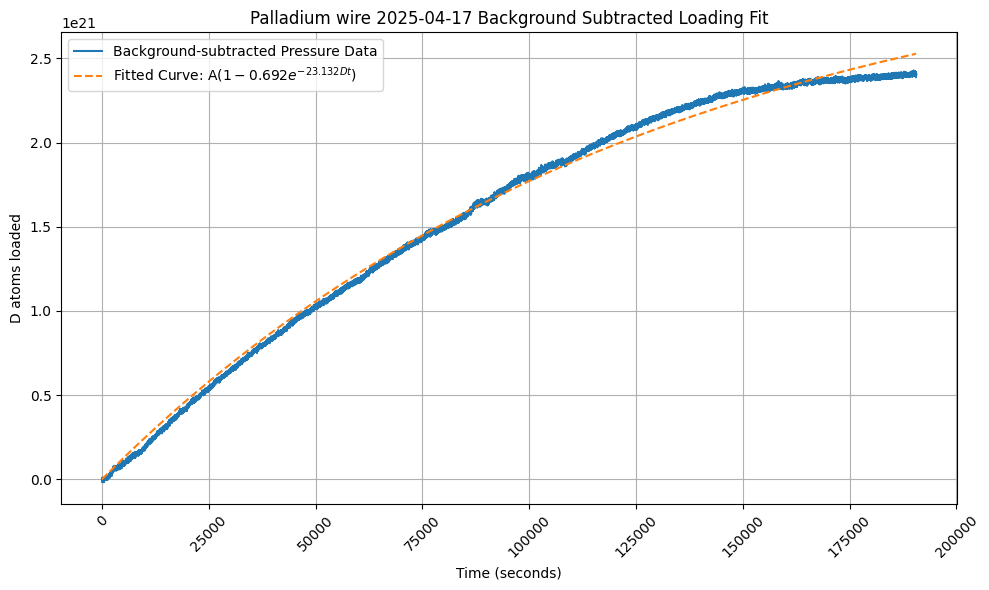

In [30]:

def exp_dependence(t, A, D):
    # This modified function starts at 0 for t=0 and approaches 0.692A as t -> infinity. A is the number of deuterium atoms on the surface, which we assume to be constant.
    return 0.692 * A * (1 -  np.exp(-23.132 * D * t))

# Get the y-data (pressure) and x-data (time index)
y_data = 2*(combined_df['$D_2$ molecules']['2025-04-17 13:05:00']-combined_df['$D_2$ molecules']['2025-04-17 13:05':'2025-04-19 18:00']) #factor of 2 to convert D2 molecules to D atoms

# Convert y_data index to seconds elapsed after the initial value
x_data = (y_data.index - y_data.index[0]).total_seconds().to_numpy()

# Initial guess for A (max y_data) and D (small positive value)
p0 = [1E21, .00001] # A, D in mm^2/s

# Perform the curve fit
try:
  #Here we fit to the later data where the approximation is supposed to hold.
    params, covariance = curve_fit(exp_dependence, x_data[x_data>10000], y_data[(y_data.index - y_data.index[0]).total_seconds().to_numpy()>10000], p0=p0)
    A_fit, D_fit = params
    print(f"Fitted parameters: A={A_fit}, D={D_fit}")

    # Generate fitted data
    y_fit = exp_dependence(x_data, A_fit, D_fit)

    # Plot the original data and the fitted curve
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Background-subtracted Pressure Data')
    plt.plot(x_data, y_fit, label=f'Fitted Curve: A$(1-0.692e^{{-23.132Dt}})$', linestyle='--') # Updated LaTeX escape sequence and label
    plt.xlabel('Time (seconds)')
    plt.ylabel('D atoms loaded') # Corrected y-axis label
    plt.xticks(rotation=45)
    plt.title(f"{meta['descriptor']} {load_pressure_df.index[0].date()} Background Subtracted Loading Fit")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    print(f"Error fitting curve: {e}. Try adjusting initial parameters (p0).")

There may be several factors confounding the model. Phase change kinetics may hinder the motion of the deuterium, causing a deviation from simple diffusion behavior. There may also be surface contaminants impeding the uptake of deuterium; the timescale for loading is much longer than typical, taking several days vs. the usual hours. Higher order terms may have contributions that we are neglecting in this approximation.